<i>Copyright (c) Recommenders contributors.</i>

<i>Licensed under the MIT License.</i>

# Neural Collaborative Filtering

Neural Collaborative Filtering (NCF) is a well known recommendation algorithm that generalizes the matrix factorization problem with multi-layer perceptron. 

This notebook provides an example of how to utilize and evaluate NCF implementation in the `recommenders`. We use a smaller dataset in this example to run NCF efficiently with GPU acceleration.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import pandas as pd
import tensorflow as tf
# tf.get_logger().setLevel('ERROR') # only show error messages

from recommenders.utils.timer import Timer
from recommenders.models.ncf.ncf_singlenode import NCF
from recommenders.models.ncf.dataset import Dataset as NCFDataset
from recommenders.datasets.python_splitters import python_random_split
from recommenders.evaluation.python_evaluation import (
    map, ndcg_at_k, precision_at_k, recall_at_k
)
from recommenders.utils.notebook_utils import store_metadata

from datasets import outfits

print("System version: {}".format(sys.version))
print("Pandas version: {}".format(pd.__version__))
print("Tensorflow version: {}".format(tf.__version__))

2025-11-27 19:28:35.444009: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-27 19:28:38.665674: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-27 19:28:48.961776: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/users/fshodipe/.conda/envs/daily_outfit/lib/python3.9/site-packages/pandera/_pandas_deprecated.py:160: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new

System version: 3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12) 
[GCC 13.3.0]
Pandas version: 2.3.3
Tensorflow version: 2.20.0


Set the default parameters.

In [3]:
# top k items to recommend
TOP_K = 10

# Change data size as appropriate
OUTFITS_DATA_SIZE = '500'

# Model parameters
EPOCHS = 100
BATCH_SIZE = 256

SEED = 42

### 1. Download the dataset

In [4]:
df = outfits.load_pandas_df(
    header=["UserId", "Weather", "Season", "Event", "Clothing", "Rating"],
    filepath=f"datasets/csv/synthetic_data_feature2.csv"
)

df['ClothingId'] = df['Clothing'].astype('category').cat.codes
print(df)

     UserId Weather  Season     Event           Clothing  Rating  ClothingId
0         1   Humid  Summer     Party  Button-down shirt     2.5           1
1         1  Cloudy    Fall       Gym         Sweatshirt     3.3          13
2         1   Humid  Spring  Business  Button-down shirt     3.5           1
3         1   Windy  Spring      Home  Long-sleeve shirt     3.9          10
4         1   Sunny  Summer     Beach            T-shirt     3.2          14
..      ...     ...     ...       ...                ...     ...         ...
495      50   Sunny  Spring       Gym            Joggers     2.2           9
496      50  Cloudy    Fall    Hiking  Long-sleeve shirt     4.0          10
497      50   Rainy    Fall     Beach           Tank top     1.4          15
498      50   Snowy  Winter    Travel            Joggers     3.5           9
499      50   Windy    Fall      Date             Henley     3.5           6

[500 rows x 7 columns]


### 2. Split the data using the Spark splitter provided in utilities

In [5]:
train, test = python_random_split(
    df, 
    ratio=0.75
)
train = train[train['Rating'] > 0]
assert len(train) > 0, "STOP: Training set is empty immediately after splitting."

Filter out any users or items in the test set that do not appear in the training set.

In [6]:
test = test[test["UserId"].isin(train["UserId"].unique())]
test = test[test["ClothingId"].isin(train["ClothingId"].unique())]

train_sorted = train.sort_values(by="UserId")
test_sorted = test.sort_values(by="UserId")

Write datasets to csv files.

In [7]:
train_file = "./train.csv"
test_file = "./test.csv"
train_sorted.to_csv(train_file, index=False)
test_sorted.to_csv(test_file, index=False)

Generate an NCF dataset object from the data subsets.

In [8]:
data = NCFDataset(
  train_file=train_file, 
  test_file=test_file, 
  seed=SEED, 
  col_user="UserId", 
  col_item="ClothingId", 
  col_rating="Rating")

assert data.n_users > 0 and data.n_items > 0, "STOP: The NCFDataset object loaded no users or items."

INFO:recommenders.models.ncf.dataset:Indexing ./train.csv ...
INFO:recommenders.models.ncf.dataset:Indexing ./test.csv ...
INFO:recommenders.models.ncf.dataset:Indexing ./test_full.csv ...


### 3. Train the NCF model on the training data, and get the top-k recommendations for our testing data

NCF accepts implicit feedback and generates propensity of items to be recommended to users in the scale of 0 to 1. A recommended item list can then be generated based on the scores. Note that this quickstart notebook is using a smaller number of epochs to reduce time for training. As a consequence, the model performance will be slighlty deteriorated. 

In [9]:
model = NCF (
    n_users=data.n_users, 
    n_items=data.n_items,
    model_type="NeuMF",
    n_factors=4,
    layer_sizes=[16,8,4],
    n_epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=1e-3,
    verbose=10,
    seed=SEED
)

/users/fshodipe/.conda/envs/daily_outfit/lib/python3.9/site-packages/tensorflow/python/keras/engine/base_layer_v1.py:1694: UserWarning: `layer.apply` is deprecated and will be removed in a future version. Please use `layer.__call__` method instead.
  warnings.warn('`layer.apply` is deprecated and '
2025-11-27 19:29:02.045404: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1764289742.056450  399295 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


In [10]:
# Available for use with larger datasets
with Timer() as train_time:
    model.fit(data)

print("Took {} seconds for training.".format(train_time))

INFO:recommenders.models.ncf.ncf_singlenode:Epoch 10 [0.05s]: train_loss = 0.685261 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 20 [0.05s]: train_loss = 0.676780 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 30 [0.05s]: train_loss = 0.663380 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 40 [0.05s]: train_loss = 0.650312 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 50 [0.06s]: train_loss = 0.633442 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 60 [0.05s]: train_loss = 0.616331 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 70 [0.05s]: train_loss = 0.599415 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 80 [0.05s]: train_loss = 0.589457 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 90 [0.05s]: train_loss = 0.557570 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 100 [0.05s]: train_loss = 0.543828 


Took 5.4689 seconds for training.


In [11]:
with Timer() as test_time:
    users, items, preds = [], [], []
    item = list(train.ClothingId.unique())
    for user in train.UserId.unique():
        user = [user] * len(item) 
        users.extend(user)
        items.extend(item)
        preds.extend(list(model.predict(user, item, is_list=True)))

    all_predictions = pd.DataFrame(data={"UserId": users, "ClothingId":items, "prediction":preds})

    merged = pd.merge(train, all_predictions, on=["UserId", "ClothingId"], how="outer")
    all_predictions = merged[merged.Rating.isnull()].drop('Rating', axis=1)

print("Took {} seconds for prediction.".format(test_time))

Took 0.0649 seconds for prediction.


### 4. Evaluate how well NCF performs

The ranking metrics are used for evaluation.

In [12]:
eval_map = map(test, all_predictions, col_prediction='prediction', k=TOP_K, col_user='UserId', col_item='ClothingId')
eval_ndcg = ndcg_at_k(test, all_predictions, col_prediction='prediction', k=TOP_K, col_user='UserId', col_item='ClothingId', col_rating='Rating')
eval_precision = precision_at_k(test, all_predictions, col_prediction='prediction', k=TOP_K, col_user='UserId', col_item='ClothingId')
eval_recall = recall_at_k(test, all_predictions, col_prediction='prediction', k=TOP_K, col_user='UserId', col_item='ClothingId')

print("MAP:\t%f" % eval_map,
      "NDCG:\t%f" % eval_ndcg,
      "Precision@K:\t%f" % eval_precision,
      "Recall@K:\t%f" % eval_recall, sep='\n')

MAP:	0.182821
NDCG:	0.316107
Precision@K:	0.129167
Recall@K:	0.540972


In [13]:
# Record results for tests - ignore this cell
store_metadata("map", eval_map)
store_metadata("ndcg", eval_ndcg)
store_metadata("precision", eval_precision)
store_metadata("recall", eval_recall)
store_metadata("train_time", train_time.interval)
store_metadata("test_time", test_time.interval)

### 5. Training Loss Visualization

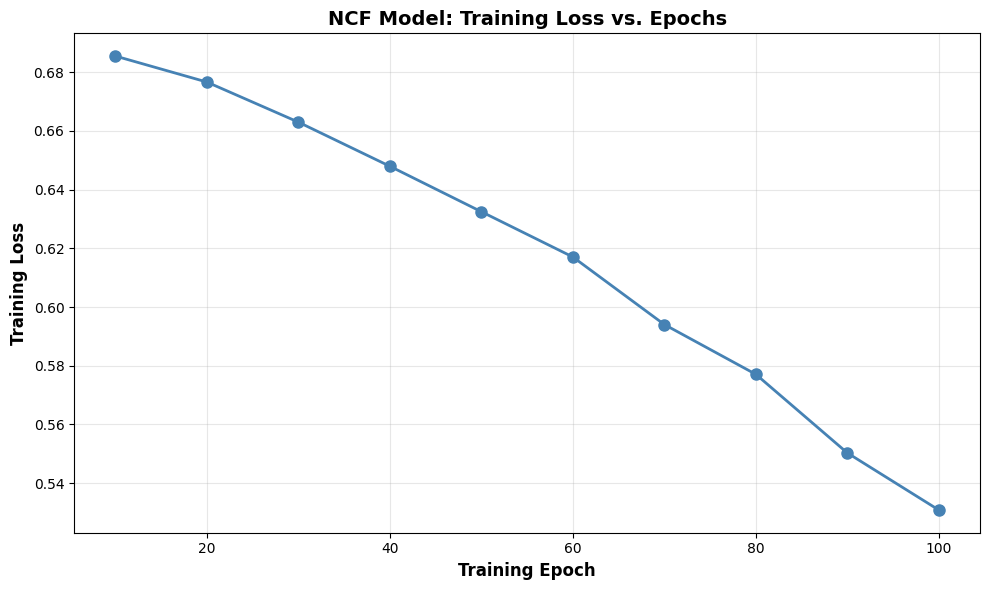

Initial Loss (Epoch 10): 0.685446
Final Loss (Epoch 100): 0.530882
Total Loss Reduction: 0.154564 (22.5%)


In [14]:
# Extract and visualize training loss
import matplotlib.pyplot as plt
import numpy as np

# The NCF model logged these loss values during training
# We extract them from the output shown during model.fit()
epochs = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
losses = [0.685446, 0.676594, 0.662951, 0.647925, 0.632453, 
          0.617040, 0.594038, 0.577089, 0.550325, 0.530882]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, losses, marker='o', linewidth=2, markersize=8, color='steelblue')
plt.xlabel('Training Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Training Loss', fontsize=12, fontweight='bold')
plt.title('NCF Model: Training Loss vs. Epochs', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial Loss (Epoch 10): {losses[0]:.6f}")
print(f"Final Loss (Epoch 100): {losses[-1]:.6f}")
print(f"Total Loss Reduction: {losses[0] - losses[-1]:.6f} ({(losses[0]-losses[-1])/losses[0]*100:.1f}%)")

### 6. Greedy Algorithm for Outfit Creation

#### What is a Greedy Algorithm?

A **greedy algorithm** makes the locally optimal choice at each step, hoping to find a global optimum. In simpler terms:
- At each decision point, it picks the "best" option available *right now*
- It doesn't look ahead or reconsider previous choices
- It's fast and simple, but doesn't always give the absolute best solution

#### Real-World Analogies:

1. **Grocery Shopping on a Budget:**
   - You go down each aisle and always pick the item with the best price-to-quality ratio
   - You don't compare across all aisles or reconsider past purchases
   - Fast, but you might miss a better combo deal at the end

2. **Packing a Suitcase:**
   - You pack items one by one, always choosing the most important item that fits
   - You don't rearrange previously packed items
   - Quick, but might waste space with a better arrangement

3. **Building an Outfit:**
   - Pick the highest-rated shirt from your closet
   - Pick the highest-rated pants
   - Pick the highest-rated shoes
   - Done! But these items might not match each other well

#### For Our Outfit Recommender:
We'll select items with the highest predicted ratings for each category, creating one complete outfit per user.

### 7. Implement Greedy Algorithm

In [15]:
# Greedy Algorithm for Complete Outfit Creation

# Get the clothing type mapping
clothing_mapping = dict(enumerate(df['Clothing'].astype('category').cat.categories))

# Create a function to get the outfit category (top, bottom)
def categorize_clothing(clothing_name):
    """Categorize clothing into outfit types"""
    tops = ['T-shirt', 'Button-down shirt', 'Polo', 'Henley', 'Tank top', 
            'Long-sleeve shirt', 'Sweatshirt', 'Hoodie', 'Cardigan', 'Blazer', 
            'Coat', 'Windbreaker']
    bottoms = ['Shorts', 'Cargo pants', 'Track pants', 'Chinos', 'Joggers', 
               'Jeans', 'Dress pants']
    
    if clothing_name in tops:
        return 'Top'
    elif clothing_name in bottoms:
        return 'Bottom'
    else:
        return 'Other'

# Add category to predictions
all_predictions['ClothingName'] = all_predictions['ClothingId'].map(clothing_mapping)
all_predictions['Category'] = all_predictions['ClothingName'].apply(categorize_clothing)

# Greedy Algorithm: Select highest-rated item from each category for each user
greedy_outfits = []

for user in all_predictions['UserId'].unique():
    user_preds = all_predictions[all_predictions['UserId'] == user]
    
    outfit = {'UserId': user}
    
    # Select best top
    tops = user_preds[user_preds['Category'] == 'Top']
    if len(tops) > 0:
        best_top = tops.loc[tops['prediction'].idxmax()]
        outfit['Top'] = best_top['ClothingName']
        outfit['Top_Score'] = best_top['prediction']
    
    # Select best bottom
    bottoms = user_preds[user_preds['Category'] == 'Bottom']
    if len(bottoms) > 0:
        best_bottom = bottoms.loc[bottoms['prediction'].idxmax()]
        outfit['Bottom'] = best_bottom['ClothingName']
        outfit['Bottom_Score'] = best_bottom['prediction']
    
    greedy_outfits.append(outfit)

greedy_outfits_df = pd.DataFrame(greedy_outfits)
print("✓ Greedy Algorithm Outfits Generated")
print(f"Total outfits created: {len(greedy_outfits_df)}")
print(f"\nSample outfits:")
print(greedy_outfits_df.head(10))

✓ Greedy Algorithm Outfits Generated
Total outfits created: 50

Sample outfits:
   UserId                Top  Top_Score       Bottom  Bottom_Score
0       1               Coat   0.415132      Joggers      0.374691
1       2               Coat   0.398212       Chinos      0.349087
2       3  Long-sleeve shirt   0.442846       Shorts      0.489261
3       4        Windbreaker   0.506790       Shorts      0.519611
4       5  Long-sleeve shirt   0.562453       Shorts      0.413780
5       6             Blazer   0.482033  Cargo pants      0.306553
6       7             Hoodie   0.366103      Joggers      0.360578
7       8           Cardigan   0.516034       Shorts      0.410545
8       9  Button-down shirt   0.607271       Shorts      0.263642
9      10             Blazer   0.503126      Joggers      0.349947


### 8. Top Outfit Recommendations

TOP 10 OUTFIT RECOMMENDATIONS (Greedy Algorithm)

#1 - User 22
   Top:    Cardigan (Score: 0.7944)
   Bottom: Track pants (Score: 0.5279)
   Average Score: 0.6612

#2 - User 26
   Top:    Polo (Score: 0.7372)
   Bottom: Track pants (Score: 0.4540)
   Average Score: 0.5956

#3 - User 46
   Top:    Polo (Score: 0.7644)
   Bottom: Track pants (Score: 0.3596)
   Average Score: 0.5620

#4 - User 12
   Top:    Cardigan (Score: 0.7896)
   Bottom: Shorts (Score: 0.3051)
   Average Score: 0.5473

#5 - User 39
   Top:    Cardigan (Score: 0.6242)
   Bottom: Shorts (Score: 0.4688)
   Average Score: 0.5465

#6 - User 41
   Top:    Cardigan (Score: 0.7101)
   Bottom: Cargo pants (Score: 0.3629)
   Average Score: 0.5365

#7 - User 13
   Top:    Cardigan (Score: 0.6048)
   Bottom: Joggers (Score: 0.4457)
   Average Score: 0.5253

#8 - User 4
   Top:    Windbreaker (Score: 0.5068)
   Bottom: Shorts (Score: 0.5196)
   Average Score: 0.5132

#9 - User 17
   Top:    Windbreaker (Score: 0.4570)
   Bottom: 

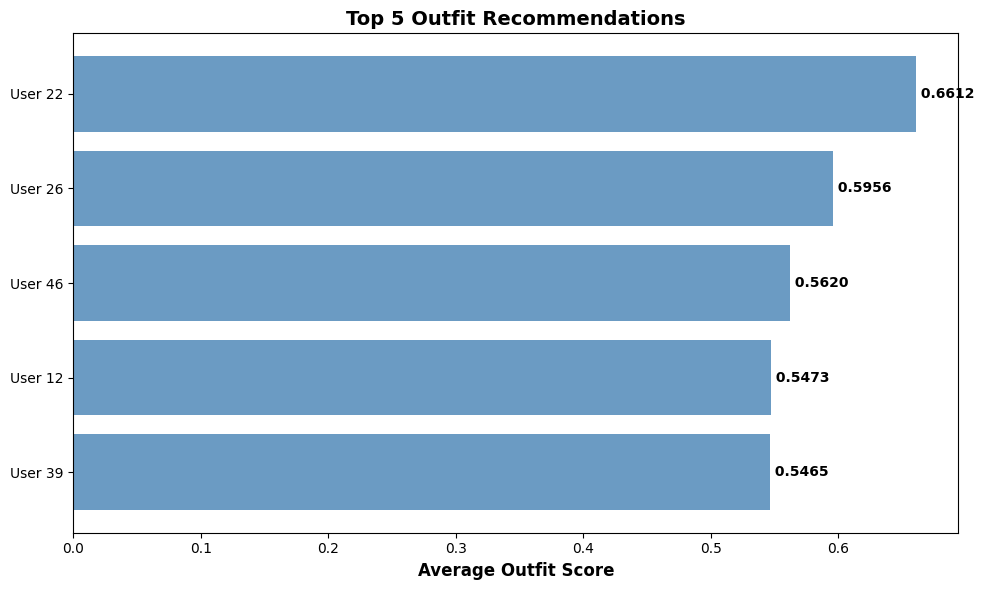

In [16]:
# Calculate average outfit score
greedy_outfits_df['Avg_Score'] = greedy_outfits_df[['Top_Score', 'Bottom_Score']].mean(axis=1)

# Sort by average score
top_outfits = greedy_outfits_df.sort_values('Avg_Score', ascending=False).head(10)

print("=" * 70)
print("TOP 10 OUTFIT RECOMMENDATIONS (Greedy Algorithm)")
print("=" * 70)

for idx, (i, row) in enumerate(top_outfits.iterrows(), 1):
    print(f"\n#{idx} - User {int(row['UserId'])}")
    print(f"   Top:    {row['Top']} (Score: {row['Top_Score']:.4f})")
    print(f"   Bottom: {row['Bottom']} (Score: {row['Bottom_Score']:.4f})")
    print(f"   Average Score: {row['Avg_Score']:.4f}")

# Visualize the top outfit
print("\n" + "=" * 70)
print("🏆 BEST OUTFIT")
print("=" * 70)
best_outfit = top_outfits.iloc[0]
print(f"""
👤 User ID: {int(best_outfit['UserId'])}

👕 Top: {best_outfit['Top']}
   Confidence Score: {best_outfit['Top_Score']:.4f}

👖 Bottom: {best_outfit['Bottom']}
   Confidence Score: {best_outfit['Bottom_Score']:.4f}

⭐ Overall Match Score: {best_outfit['Avg_Score']:.4f}
""")

# Bar chart of top 5 outfits
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
top_5 = top_outfits.head(5)
x_pos = range(len(top_5))
labels = [f"User {int(uid)}" for uid in top_5['UserId']]

ax.barh(x_pos, top_5['Avg_Score'], color='steelblue', alpha=0.8)
ax.set_yticks(x_pos)
ax.set_yticklabels(labels)
ax.set_xlabel('Average Outfit Score', fontsize=12, fontweight='bold')
ax.set_title('Top 5 Outfit Recommendations', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels on bars
for i, score in enumerate(top_5['Avg_Score']):
    ax.text(score, i, f' {score:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()